# Stage 2: Predicting Hospital Readmissions
This model is trained **only on patients who were admitted** to predict if they will be readmitted.

In [1]:
import pandas as pd
import numpy as np
import os
import pathlib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, roc_auc_score, auc, confusion_matrix

# 1. Define Paths (portable — resolves repo root from this notebook's location,
#    overridable via PROJECT_D_BASE env var for CI / other machines)
base_path = os.environ.get(
    "PROJECT_D_BASE",
    str(pathlib.Path(os.getcwd()).resolve().parents[1])
)
input_file = os.path.join(base_path, "machineLearning", "csv", "ml_ready_dataset.csv")

# 2. Load the data
df = pd.read_csv(input_file)
print(f"Loading dataset from: {input_file}")
print(f"✅ Full dataset loaded successfully. Total shape: {df.shape}")

Loading dataset from: C:\Users\thira\Documents\GitHub\project-d\machineLearning\csv\ml_ready_dataset.csv
✅ Full dataset loaded successfully. Total shape: (62135, 26)


### 1. Filter for Stage 2 (Admitted Patients Only) & Handle Leakage


In [2]:
# 1. Filter: We only care about patients who were admitted
df_admitted = df[df['Admitted_Yes_No'] == 1].copy()
print(f"✅ Filtered to Admitted patients only. New shape: {df_admitted.shape}")

# 2. Define the new target variable
target = 'Readmitted_Yes_No'

# 3. Handle Leakage & Constants
cols_to_drop = ['Admitted_Yes_No', 'Num_Admissions', 'Num_Visits', target]

X = df_admitted.drop(columns=cols_to_drop, errors='ignore')
y = df_admitted[target]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the raw class imbalance for Readmissions
print("\nClass Distribution (Readmitted vs Not Readmitted):")
print(y.value_counts(normalize=True) * 100)


✅ Filtered to Admitted patients only. New shape: (7999, 26)

Features (X) shape: (7999, 22)
Target (y) shape: (7999,)

Class Distribution (Readmitted vs Not Readmitted):
Readmitted_Yes_No
0    72.146518
1    27.853482
Name: proportion, dtype: float64


In [3]:
# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} patients")
print(f"✅ Testing set: {X_test.shape[0]} patients")


✅ Training set: 6399 patients
✅ Testing set: 1600 patients


### 2. Smart Preprocessing & Scaling


In [4]:
print("--- STEP 1: SMART PREPROCESSING & SCALING ---")

# Notice we added 'Avg_LOS' to the continuous list for Stage 2!
continuous_cols = [
    'AGE', 
    'Avg_LOS',
    'Total_Meds_Count', 
    'Total_Unique_Diagnoses', 
    'Severity_Encoded'
]

binary_cols = [col for col in X_train.columns if col not in continuous_cols]

print(f"Identified {len(continuous_cols)} continuous features to scale.")
print(f"Identified {len(binary_cols)} binary features to leave unscaled.\n")

# 2. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', 'passthrough', binary_cols)
    ])

# 3. Fit and Transform the data
X_train_processed_array = preprocessor.fit_transform(X_train)
X_test_processed_array = preprocessor.transform(X_test)

# 4. Reconstruct Pandas DataFrames
new_column_order = continuous_cols + binary_cols

X_train_final = pd.DataFrame(X_train_processed_array, columns=new_column_order, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed_array, columns=new_column_order, index=X_test.index)

print(f"✅ Final Training features shape: {X_train_final.shape}")
print("Ready for Model Training!")


--- STEP 1: SMART PREPROCESSING & SCALING ---
Identified 5 continuous features to scale.
Identified 17 binary features to leave unscaled.

✅ Final Training features shape: (6399, 22)
Ready for Model Training!


### 3. Model Training & Hyperparameter Tuning


In [5]:
print("--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---")

negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_weight = negative_cases / positive_cases

print(f"Dataset Imbalance Ratio: 1 Readmission for every {scale_weight:.2f} Non-Readmissions.\n")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- 1. Logistic Regression ---      
print("Training & Tuning Logistic Regression...")
start_time = time.time()

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_tuned = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
lr_tuned.fit(X_train_final, y_train)
lr_model = lr_tuned.best_estimator_

print(f"✅ LR Tuned & Trained in {time.time() - start_time:.2f} seconds")

# --- 2. Random Forest ---    
print("\nTraining & Tuning Random Forest...")    
start_time = time.time()

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_final, y_train)  
rf_model = rf_tuned.best_estimator_

print(f"✅ RF Tuned & Trained in {time.time() - start_time:.2f} seconds")

# --- 3. XGBoost ---
print("\nTraining & Tuning XGBoost...")
start_time = time.time()

xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_tuned = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1', 
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_final, y_train)
xgb_model = xgb_tuned.best_estimator_

print(f"✅ XGBoost Tuned & Trained in {time.time() - start_time:.2f} seconds")
print(f"🏆 XGBoost Best Parameters: {xgb_tuned.best_params_}")


--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---
Dataset Imbalance Ratio: 1 Readmission for every 2.59 Non-Readmissions.

Training & Tuning Logistic Regression...


✅ LR Tuned & Trained in 3.97 seconds

Training & Tuning Random Forest...


✅ RF Tuned & Trained in 6.95 seconds

Training & Tuning XGBoost...


✅ XGBoost Tuned & Trained in 1.92 seconds
🏆 XGBoost Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


### 4. Evaluation & Threshold Optimization


In [6]:
print("--- PHASE 4: EVALUATION ON TEST SET (WITH THRESHOLD OPTIMIZATION) ---\n")

def evaluate_model_with_optimal_threshold(model, name, X_train, y_train, X_test, y_test):
    # 1. Find optimal threshold using Training Data to prevent leakage
    y_train_proba = model.predict_proba(X_train)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    # 2. Apply that learned threshold to Test Data
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)
    
    # 3. Evaluate
    test_precisions, test_recalls, _ = precision_recall_curve(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    pr_auc = auc(test_recalls, test_precisions)
    
    print(f"--- {name} ---")
    print(f"🎯 Optimal Threshold (Learned from Train): {optimal_threshold:.4f}")
    print(f"📈 ROC-AUC Score: {roc_auc:.4f} | PR-AUC Score: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred_optimal))
    print("\n")
    
    return y_test_proba, y_pred_optimal, optimal_threshold

y_proba_lr,  y_pred_lr,  optimal_threshold_lr  = evaluate_model_with_optimal_threshold(
    lr_model,  "LOGISTIC REGRESSION", X_train_final, y_train, X_test_final, y_test)
y_proba_rf,  y_pred_rf,  optimal_threshold_rf  = evaluate_model_with_optimal_threshold(
    rf_model,  "RANDOM FOREST",       X_train_final, y_train, X_test_final, y_test)
y_proba_xgb, y_pred_xgb, optimal_threshold_xgb = evaluate_model_with_optimal_threshold(
    xgb_model, "XGBOOST",             X_train_final, y_train, X_test_final, y_test)

--- PHASE 4: EVALUATION ON TEST SET (WITH THRESHOLD OPTIMIZATION) ---

--- LOGISTIC REGRESSION ---
🎯 Optimal Threshold (Learned from Train): 0.2466
📈 ROC-AUC Score: 0.8220 | PR-AUC Score: 0.6227
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1154
           1       0.55      0.73      0.63       446

    accuracy                           0.76      1600
   macro avg       0.71      0.75      0.72      1600
weighted avg       0.79      0.76      0.77      1600



--- RANDOM FOREST ---
🎯 Optimal Threshold (Learned from Train): 0.3938
📈 ROC-AUC Score: 0.8696 | PR-AUC Score: 0.7414
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1154
           1       0.67      0.68      0.68       446

    accuracy                           0.82      1600
   macro avg       0.78      0.78      0.78      1600
weighted avg       0.82      0.82      0.82      1600



--- XGBOOST ---
🎯 Optimal Thr

### 4.1 Avg_LOS Temporal-Leakage Ablation

`Avg_LOS` is computed as the mean length-of-stay across **all** claims belonging to a patient (see `dataPreprocessing/04_aggregate_patients`). If those claims include the readmission encounter itself, the feature partially encodes the outcome — a form of temporal leakage.

This cell retrains the champion XGBoost with `Avg_LOS` **removed** and compares ROC-AUC / PR-AUC against the headline model. The decision rule is: if ΔROC-AUC exceeds 0.05, the leakage is material and the headline 0.876 must be qualified in the final report. The result is recorded regardless, so the Limitations section can cite the exact delta.

In [7]:
print("--- PHASE 4.1: Avg_LOS ABLATION (temporal-leakage check) ---\n")

# Retrain XGBoost without Avg_LOS, keeping every other hyperparameter identical.
X_train_noLOS = X_train_final.drop(columns=['Avg_LOS'])
X_test_noLOS  = X_test_final.drop(columns=['Avg_LOS'])

xgb_noLOS = XGBClassifier(**xgb_tuned.best_params_, eval_metric='logloss')
xgb_noLOS.fit(X_train_noLOS, y_train)

# Evaluate the ablated model using the same train-learned-threshold pattern.
y_proba_noLOS, y_pred_noLOS, optimal_threshold_noLOS = evaluate_model_with_optimal_threshold(
    xgb_noLOS, "XGBOOST (NO Avg_LOS)",
    X_train_noLOS, y_train, X_test_noLOS, y_test
)

# Compute delta vs. the headline XGBoost run.
roc_full   = roc_auc_score(y_test, y_proba_xgb)
roc_noLOS  = roc_auc_score(y_test, y_proba_noLOS)
prec_full, rec_full, _ = precision_recall_curve(y_test, y_proba_xgb)
prec_nl,   rec_nl,   _ = precision_recall_curve(y_test, y_proba_noLOS)
pr_full   = auc(rec_full, prec_full)
pr_noLOS  = auc(rec_nl, prec_nl)

delta_roc = roc_full - roc_noLOS
delta_pr  = pr_full  - pr_noLOS

print(f"\n=== ABLATION SUMMARY ===")
print(f"ROC-AUC:  full={roc_full:.4f}   noLOS={roc_noLOS:.4f}   Δ={delta_roc:+.4f}")
print(f"PR-AUC:   full={pr_full:.4f}   noLOS={pr_noLOS:.4f}   Δ={delta_pr:+.4f}")
if delta_roc > 0.05:
    print("⚠ Δ ROC-AUC > 0.05 — Avg_LOS likely leaks temporal information. Report BOTH numbers in the capstone.")
else:
    print("✅ Δ ROC-AUC ≤ 0.05 — Avg_LOS is not materially leaking; headline number stands.")

--- PHASE 4.1: Avg_LOS ABLATION (temporal-leakage check) ---

--- XGBOOST (NO Avg_LOS) ---
🎯 Optimal Threshold (Learned from Train): 0.3128
📈 ROC-AUC Score: 0.8131 | PR-AUC Score: 0.6046
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1154
           1       0.53      0.74      0.62       446

    accuracy                           0.75      1600
   macro avg       0.71      0.74      0.72      1600
weighted avg       0.78      0.75      0.76      1600




=== ABLATION SUMMARY ===
ROC-AUC:  full=0.8757   noLOS=0.8131   Δ=+0.0626
PR-AUC:   full=0.7628   noLOS=0.6046   Δ=+0.1583
⚠ Δ ROC-AUC > 0.05 — Avg_LOS likely leaks temporal information. Report BOTH numbers in the capstone.


### 5. Visual Diagnostics


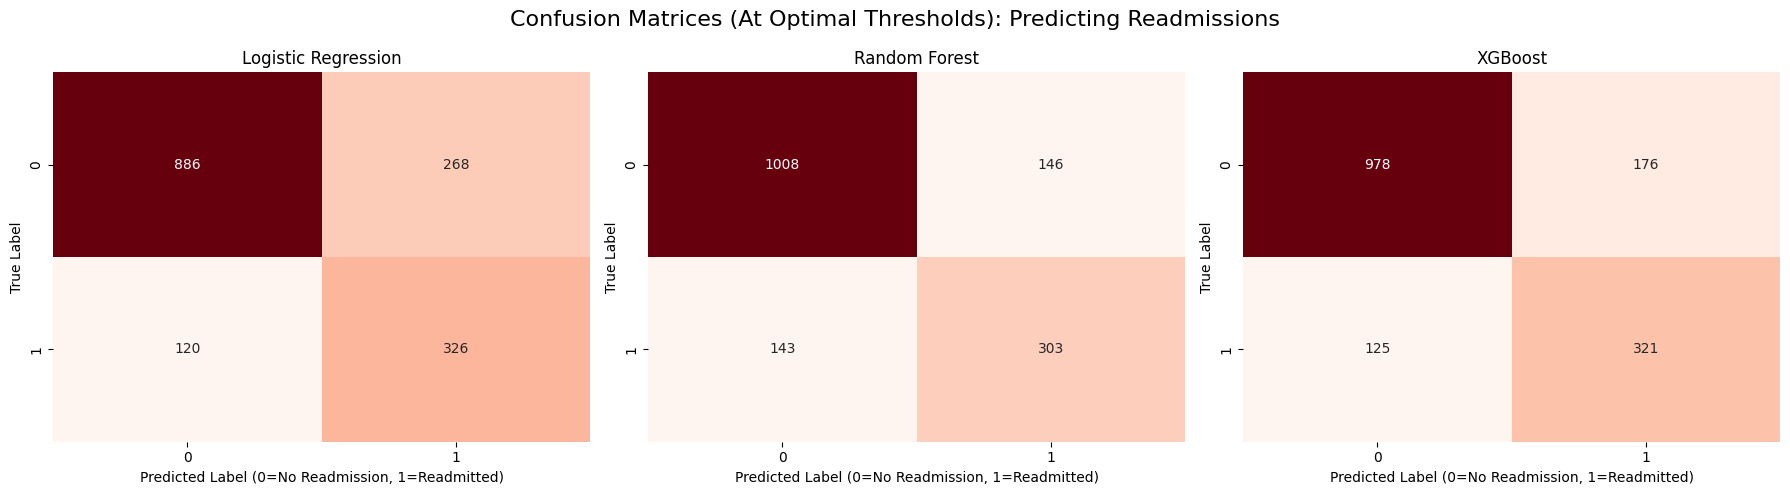

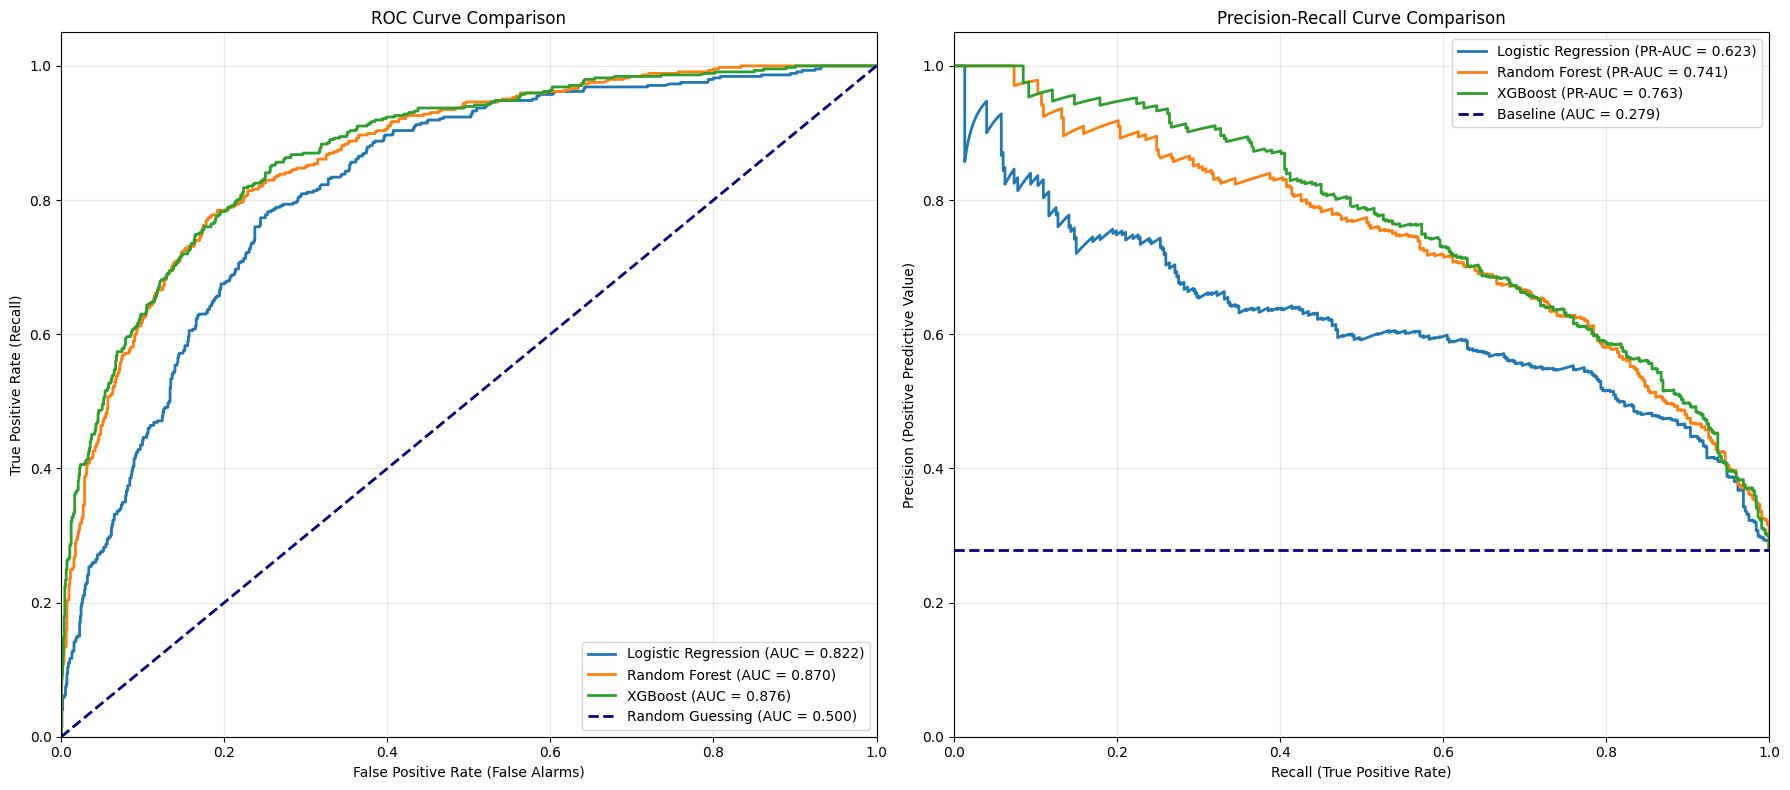

In [8]:
# Create a figure with 3 subplots for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (At Optimal Thresholds): Predicting Readmissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=No Readmission, 1=Readmitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# --- ROC and PR Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('XGBoost', y_proba_xgb)
]

for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

for name, y_proba in models_proba:
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    ax2.plot(recalls, precisions, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

baseline = y_test.sum() / len(y_test)
ax2.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline (AUC = {baseline:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (True Positive Rate)')
ax2.set_ylabel('Precision (Positive Predictive Value)')
ax2.set_title('Precision-Recall Curve Comparison')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 6. Model Interpretability (What drives a Readmission?)


--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---



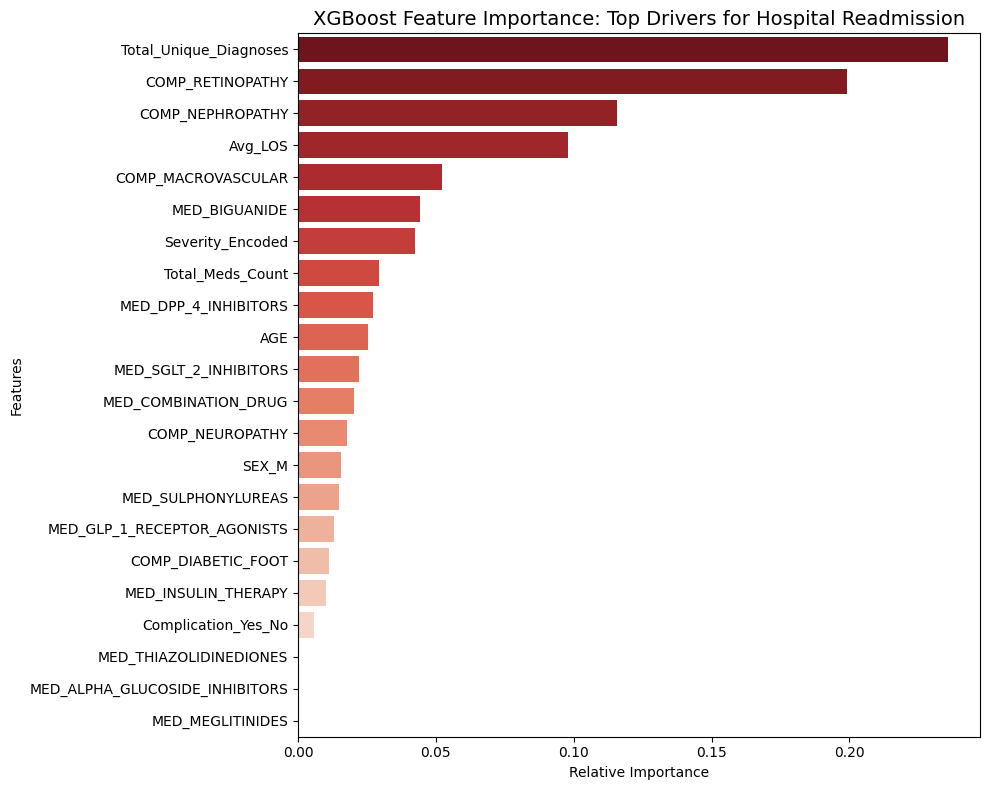

Top 5 Leading Indicators for Readmission:
               Feature  Importance
Total_Unique_Diagnoses    0.235653
      COMP_RETINOPATHY    0.199022
      COMP_NEPHROPATHY    0.115868
               Avg_LOS    0.097845
    COMP_MACROVASCULAR    0.052220


In [9]:
print("--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---\n")

xgb_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, hue='Feature', palette='Reds_r', legend=False)
plt.title('XGBoost Feature Importance: Top Drivers for Hospital Readmission', fontsize=14)
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Leading Indicators for Readmission:")
print(xgb_importance.head(5).to_string(index=False))


In [10]:
import joblib
import json
import os

print("--- PHASE 7: EXPORTING READMISSION MODELS + THRESHOLDS ---")
model_dir = os.path.join(base_path, "machineLearning", "models")
os.makedirs(model_dir, exist_ok=True)

# 1. Trained readmission classifiers + fitted preprocessor
joblib.dump(lr_model,     os.path.join(model_dir, "logistic_regression_readmission.pkl"))
joblib.dump(rf_model,     os.path.join(model_dir, "random_forest_readmission.pkl"))
joblib.dump(xgb_model,    os.path.join(model_dir, "xgboost_readmission.pkl"))
joblib.dump(preprocessor, os.path.join(model_dir, "standard_scaler_readmission.pkl"))

# 2. Merge readmission thresholds into the shared thresholds.json.
#    Track A writes the *_admission keys; this cell adds the *_readmission keys
#    without clobbering the admission ones.
thresholds_path = os.path.join(model_dir, "thresholds.json")
thresholds = {}
if os.path.exists(thresholds_path):
    try:
        with open(thresholds_path) as f:
            thresholds = json.load(f)
    except json.JSONDecodeError:
        thresholds = {}

thresholds.update({
    "lr_readmission":        float(optimal_threshold_lr),
    "rf_readmission":        float(optimal_threshold_rf),
    "xgb_readmission":       float(optimal_threshold_xgb),
    "xgb_readmission_noLOS": float(optimal_threshold_noLOS),
})

with open(thresholds_path, "w") as f:
    json.dump(thresholds, f, indent=2)

print("All readmission models exported and thresholds.json updated.")

--- PHASE 7: EXPORTING READMISSION MODELS + THRESHOLDS ---
All readmission models exported and thresholds.json updated.


C:\Users\thira\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- PHASE 6: SHAP VALUES FOR CLINICAL INTERPRETABILITY ---

1. GLOBAL DRIVERS: What pushes risk up or down across the entire hospital?


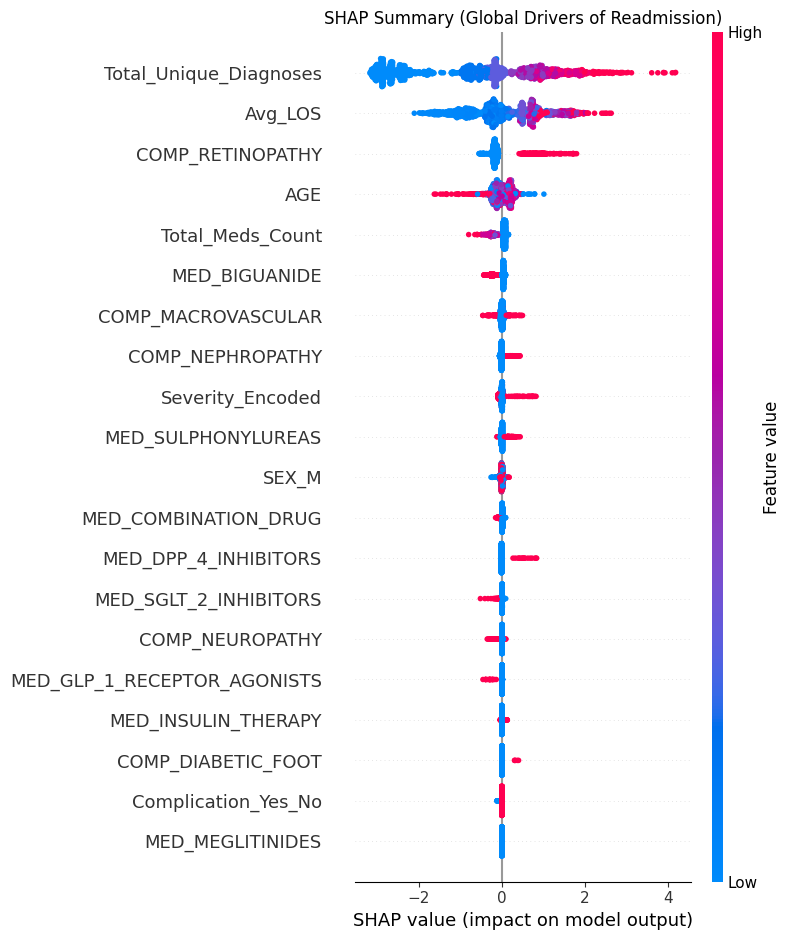


2. LOCAL EXPLANATION: Breaking down risk for a single patient.

Analyzing Patient Index: 0 (True Positive - Readmitted)


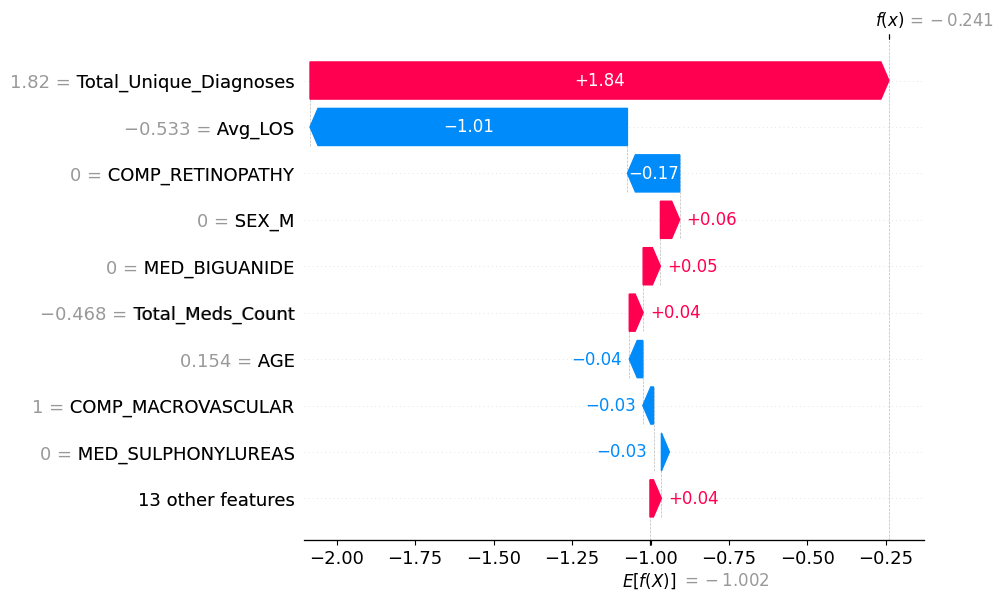

In [11]:
import shap

print("--- PHASE 6: SHAP VALUES FOR CLINICAL INTERPRETABILITY ---")

# Initialize the SHAP Explainer using the winning XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the Test Set (this can take a moment)
shap_values = explainer.shap_values(X_test_final)

# 1. Global Interpretability (Beeswarm Plot)
print("\n1. GLOBAL DRIVERS: What pushes risk up or down across the entire hospital?")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_final, show=False)
plt.title("SHAP Summary (Global Drivers of Readmission)")
plt.tight_layout()
plt.show()

# 2. Local Interpretability (Individual Patient Explanations)
print("\n2. LOCAL EXPLANATION: Breaking down risk for a single patient.")

# Find a True Positive patient (Model correctly predicted a Readmission)
true_positives = np.where((y_test.values == 1) & (y_pred_xgb == 1))[0]
patient_idx = true_positives[0] # Take the first one

print(f"\nAnalyzing Patient Index: {patient_idx} (True Positive - Readmitted)")

# Generate Waterfall Plot for this specific patient
shap.plots.waterfall(shap.Explanation(values=shap_values[patient_idx], 
                                      base_values=explainer.expected_value, 
                                      data=X_test_final.iloc[patient_idx], 
                                      feature_names=X_test_final.columns))


### 8. Persist Track B Plots to Disk
Track A saves its diagnostic plots to `machineLearning/plots/` so they can be embedded in the final report without re-running the notebook. This cell does the same for Track B, using a `05_` to `08_` filename prefix so the four admission PNGs already on disk are not overwritten.

In [12]:
print("--- PHASE 6.5: SAVING READMISSION METRICS TO DISK ---\n")

plots_dir = os.path.join(base_path, "machineLearning", "plots")
os.makedirs(plots_dir, exist_ok=True)

# 1. Classification reports (text file) — encoding="utf-8" because the ablation summary
#    writes the Δ character, which would otherwise crash on Windows default cp1252.
report_path = os.path.join(plots_dir, "05_Readmission_Classification_Reports.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("--- LOGISTIC REGRESSION ---\n")
    f.write(classification_report(y_test, y_pred_lr))
    f.write("\n\n--- RANDOM FOREST ---\n")
    f.write(classification_report(y_test, y_pred_rf))
    f.write("\n\n--- XGBOOST ---\n")
    f.write(classification_report(y_test, y_pred_xgb))
    f.write("\n\n--- XGBOOST (NO Avg_LOS ablation) ---\n")
    f.write(classification_report(y_test, y_pred_noLOS))
    f.write(f"\nABLATION \u0394ROC-AUC: {delta_roc:+.4f}   \u0394PR-AUC: {delta_pr:+.4f}\n")
print("Saved text reports to: 05_Readmission_Classification_Reports.txt")

# 2. Confusion matrices (3-panel PNG)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Predicting PMCare Readmissions', fontsize=16)
models = [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]
for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted (0=No Readmission, 1=Readmitted)')
    axes[i].set_ylabel('True Label')
plt.tight_layout()
cm_path = os.path.join(plots_dir, "06_Readmission_Confusion_Matrices.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.close()
print("Saved confusion matrices to: 06_Readmission_Confusion_Matrices.png")

# 3. ROC curve (3-model overlay)
plt.figure(figsize=(10, 8))
for name, y_proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Readmission Risk')
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
roc_path = os.path.join(plots_dir, "07_Readmission_ROC_Curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close()
print("Saved ROC curve to: 07_Readmission_ROC_Curve.png")

# 4. XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, hue='Feature', palette='Reds_r', legend=False)
plt.title('XGBoost Feature Importance: Top Drivers for Readmission', fontsize=14)
plt.xlabel('Relative Importance'); plt.ylabel('Features')
plt.tight_layout()
imp_path = os.path.join(plots_dir, "08_Readmission_XGBoost_Importance.png")
plt.savefig(imp_path, dpi=300, bbox_inches='tight')
plt.close()
print("Saved XGBoost importance plot to: 08_Readmission_XGBoost_Importance.png")

print("\nAll readmission evaluation assets saved to disk.")

--- PHASE 6.5: SAVING READMISSION METRICS TO DISK ---

Saved text reports to: 05_Readmission_Classification_Reports.txt


Saved confusion matrices to: 06_Readmission_Confusion_Matrices.png


Saved ROC curve to: 07_Readmission_ROC_Curve.png


Saved XGBoost importance plot to: 08_Readmission_XGBoost_Importance.png

All readmission evaluation assets saved to disk.
